## 5.3 전이 학습

큰 데이터 셋을 확보하기 어려움. 이런 현실적인 문제를 해결한 것이 전이 학습. 전이 학습이란 이미지넷처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 해결하려는 과제에 맞게 보정해서 사용하는 것을 의미. 이때 아주 큰 데이터셋을 사용하여 훈련된 모델을 사전 훈련된 모델이라고 함.

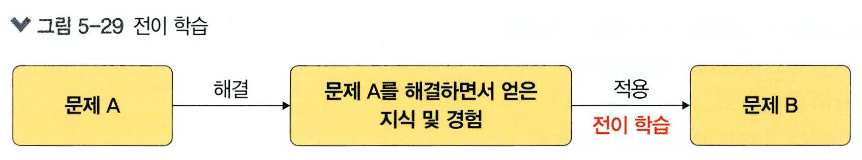

### 5.3.1 특성 추출 기법
- 특성 추출: ImageNet 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만드는 방법. 나머지 계층들은 학습되지 않도록 함.
  - 합성곱층: 합성곱층과 풀링층으로 구성
  - 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킴.

[사용 가능한 이미지 분류 모델]
- Xception
- Inception V3
- ResNet50
- VGG16
- VGG19
- MobileNet

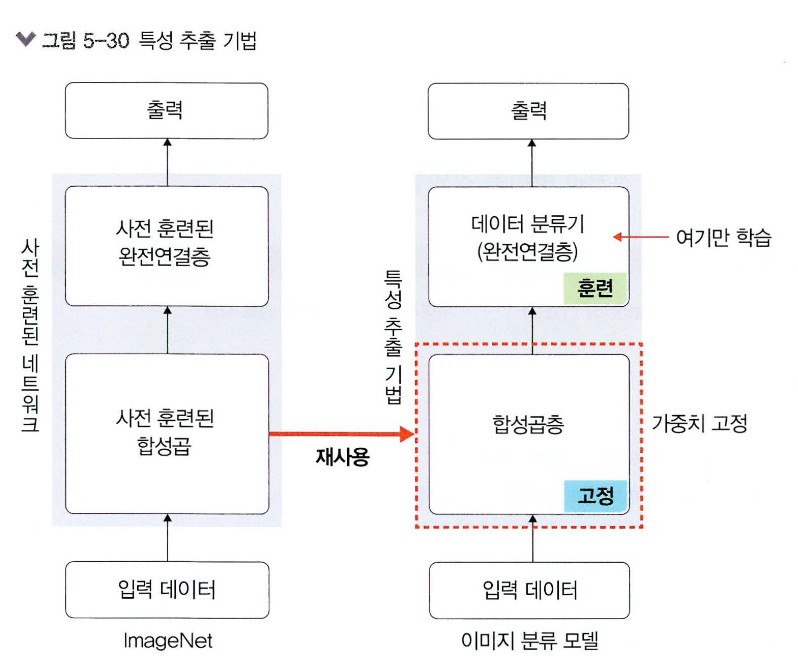

In [1]:
# 라이브러리 설치
!pip install opencv-python

In [6]:
# 라이브러리 호출
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [13]:
# 이미지 데이터 전처리 방법 정의
data_path = '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/train'
transform = transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform = transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 32,
    num_workers = 8,
    shuffle = True
)
print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


1. torchvision.transform은 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 변환해 준다.

  [파라미터]
  - transforms.Resize(): 이미지 크기를 조정
  - transforms.RandomResized(): 이미지를 랜덤한 크기 및 비율로 자름
  - transforms.RandomHorizontalFlip(): 이미지를 랜덤하게 수평으로 뒤집음
  - transforms.ToTensor(): 이미지 데이터를 텐서로 변환

2. datasets.ImageFolder는 데이터로더가 데이터를 불러올 대상과 방법 정의.

  [파라미터]
  - 불러올 데이터가 위치한 경로
  - transform: 이미지 데이터에 대한 전처리

3. DataLoader는 데이터를 불러오는 부분. 한 번에 불러올 데이터양을 결정하는 batch_size를 지정.

#### Note: RandomResizedCrop 자세히 알아보기

In [1]:
!pip install mxnet
!pip install --user mxnet

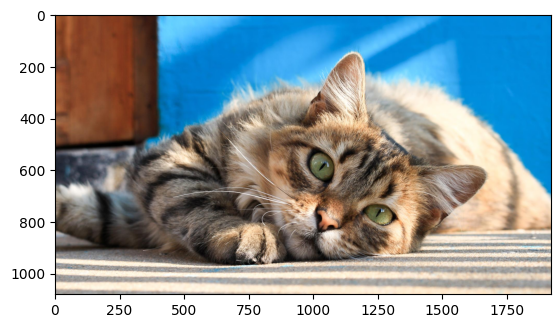

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/cat.jpg'
example_image = Image.open(image_path)
plt.imshow(example_image)

In [10]:
def show_images(imgs, num_rows, num_cols, scale=2):
  # imgs[0] is (C, H, W) if from ToTensor()
  # aspect_ratio = Height / Width
  aspect_ratio = imgs[0].shape[1] / imgs[0].shape[2] # Corrected aspect ratio calculation
  figsize = (num_cols * scale, num_rows * scale * aspect_ratio)
  _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
  for i in range(num_rows):
    for j in range(num_cols):
      # imgs[i * num_cols + j] is a PyTorch tensor (C, H, W)
      # Permute to (H, W, C) and convert to numpy for imshow
      axes[i][j].imshow(imgs[i * num_cols + j].permute(1, 2, 0).numpy())
      axes[i][j].axes.get_xaxis().set_visible(False)
      axes[i][j].axes.get_yaxis().set_visible(False)
  plt.subplots_adjust(hspace=0.1, wspace=0)
  return axes


def apply(img, aug, num_rows=2, num_cols=4, scale=3):
  Y = [aug(img) for _ in range(num_rows * num_cols)]
  show_images(Y, num_rows, num_cols, scale)

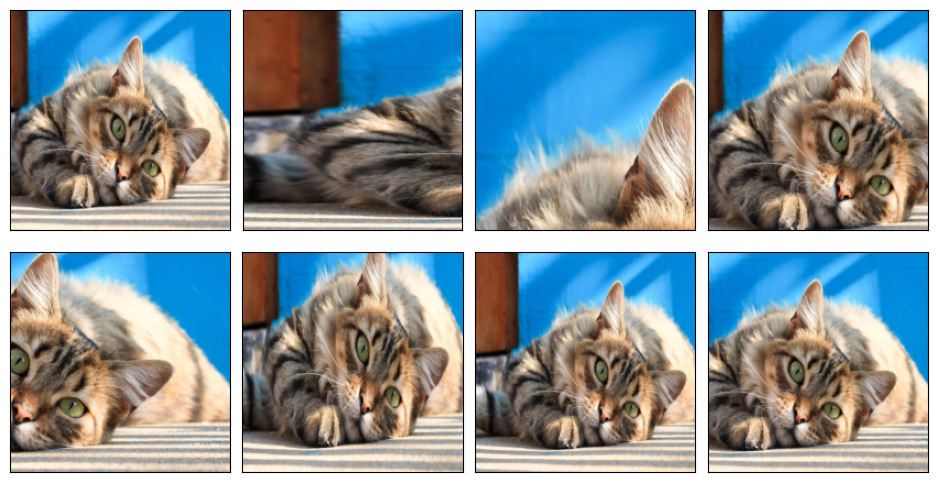

In [11]:
shape_aug = transforms.Compose([
    transforms.RandomResizedCrop(size=(200,200),
                                 scale=(0.1,1),
                                 ratio=(0.5,2)),
    transforms.ToTensor() # Add this to convert to tensor
])
apply(example_image, shape_aug)

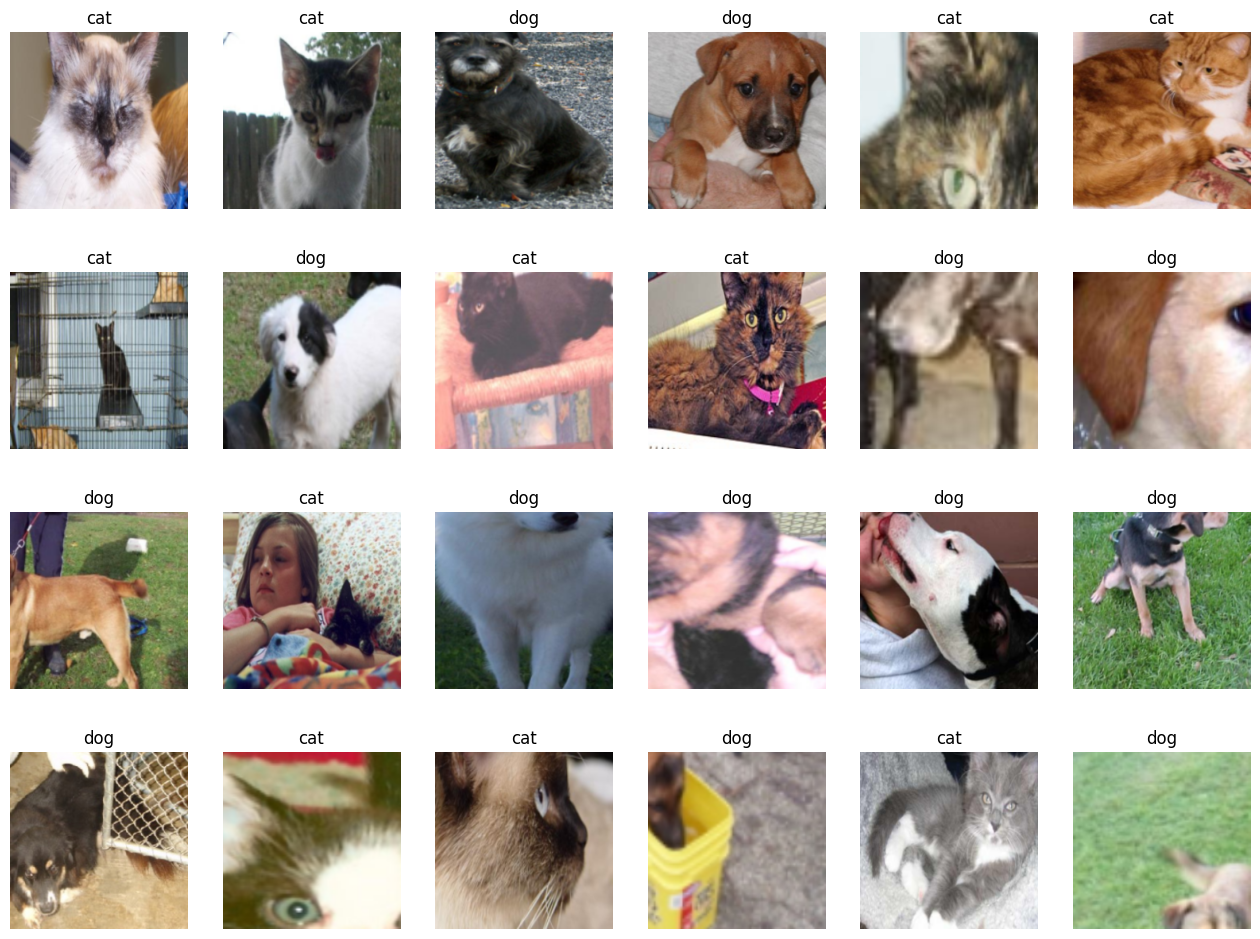

In [14]:
# 학습에 사용될 이미지 출력
import numpy as np
samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))
for i in range(24):
  a = fig.add_subplot(4, 6, i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

- np.transpose는 행과 열을 바꿈으로써 행렬의 차원을 바꿔줌
- 행렬의 차원을 변경하는 이유는 행렬의 내적 연산 때문

In [15]:
# 사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 100MB/s]


[ResNet18]

50계층으로 구성된 합성곱 신경망. 데이터베이스의 100만개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공하고 있음.

In [16]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False

set_parameter_requires_grad(resnet18)

- requires_grad=False: 역전파 파라미터들에 대한 변화를 계산할 필요가 없음을 나타냄

In [17]:
# ResNet18에 완전연결층 추가
resnet18.fc = nn.Linear(512, 2)

In [18]:
# 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0128,  0.0353, -0.0340,  ..., -0.0413, -0.0221,  0.0186],
        [ 0.0279, -0.0139,  0.0017,  ..., -0.0243,  0.0316, -0.0011]])
fc.bias tensor([-0.0085, -0.0370])


In [19]:
# 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn.Linear(512,2)

for param in model.fc.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
# 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13,
                is_train=True):
  since = time.time()
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      running_corrects += torch.sum(preds==labels.data)

    epoch_loss = running_loss/len(dataloaders.dataset)
    epoch_acc = running_corrects.double()/len(dataloaders.dataset)

    print('Loss:{:.4f} Acc:{:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(),
               os.path.join('/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/''{0:0=2d}.pth'.format(epoch)))
    print()

  time_elapsed = time.time()
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60,
                                                      time_elapsed % 60))
  print('Best ACC: {:.4f}'.format(best_acc))
  return acc_history, loss_history

In [23]:
# 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)
    print("/t", name)

optimizer = optim.Adam(params_to_update)

/t fc.weight
/t fc.bias


In [24]:
# 모델 학습
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion,
                                              optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss:0.0215 Acc:0.6234

Epoch 1/12
----------
Loss:0.0144 Acc:0.8156

Epoch 2/12
----------
Loss:0.0115 Acc:0.8649

Epoch 3/12
----------
Loss:0.0103 Acc:0.8857

Epoch 4/12
----------
Loss:0.0102 Acc:0.8909

Epoch 5/12
----------
Loss:0.0099 Acc:0.9013

Epoch 6/12
----------
Loss:0.0107 Acc:0.8701

Epoch 7/12
----------
Loss:0.0080 Acc:0.9325

Epoch 8/12
----------
Loss:0.0083 Acc:0.9065

Epoch 9/12
----------
Loss:0.0081 Acc:0.9299

Epoch 10/12
----------
Loss:0.0087 Acc:0.9143

Epoch 11/12
----------
Loss:0.0113 Acc:0.8883

Epoch 12/12
----------
Loss:0.0095 Acc:0.8623

Training complete in 29396504m 36s
Best ACC: 0.9325


In [25]:
# 테스트 데이터 호출 및 전처리
test_path = '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/test'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ]
)
test_dataset = torchvision.datasets.ImageFolder(
    root = test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)
print(len(test_dataset))

98


In [30]:
# 테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/'+'*.pth')
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():
        outputs = model(inputs) # 'models(inputs)' 대신 'model(inputs)'으로 수정

      _, preds = torch.max(outputs.data, 1)
      preds[preds>=0.5] = 1
      preds[preds< 0.5] = 0
      running_corrects += preds.eq(labels.cpu()).int().sum()

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
      acc_history.append(epoch_acc.item())
      print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,
                                                          time_elapsed % 60))
    print('Best ACC: {:.4f}'.format(best_acc))

    return acc_history

In [31]:
# 테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/00.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/01.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/02.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/03.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/04.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/05.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/06.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/07.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/08.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/09.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data/catanddog/10.pth', '/content/drive/MyDrive/data/딥러닝 파이토치 교과ᄉ

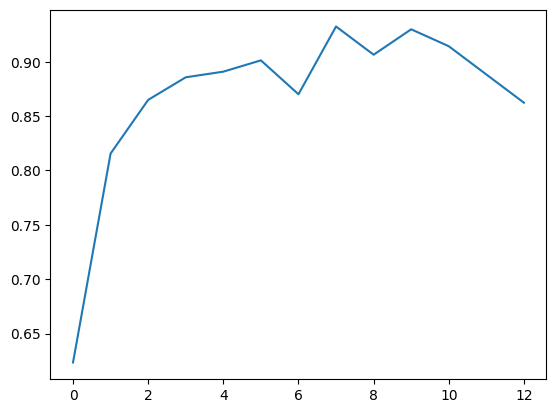

In [32]:
# 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

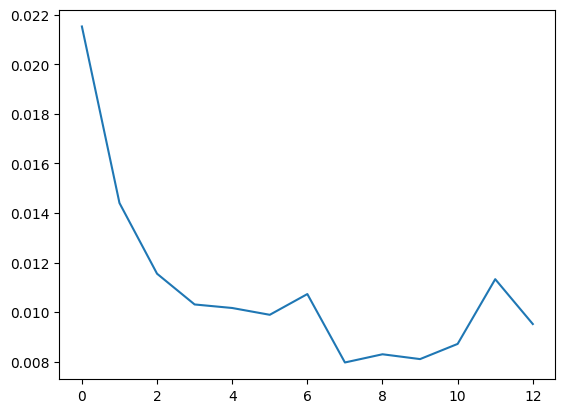

In [33]:
# 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [34]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy()
  image = image.transpose(1,2,0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0,1)
  return image

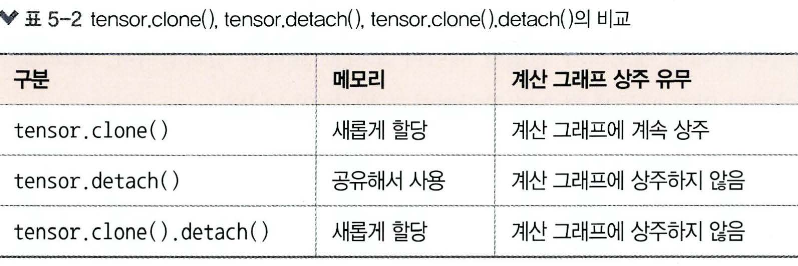

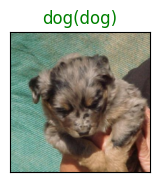

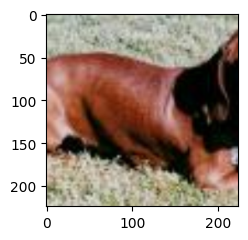

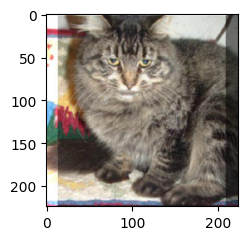

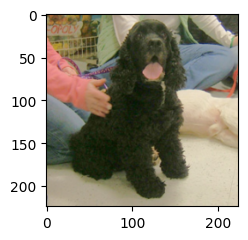

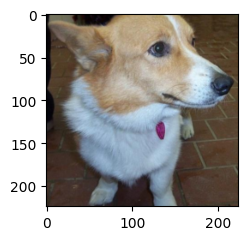

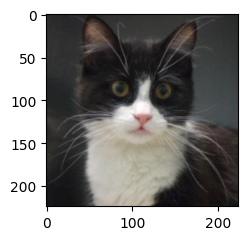

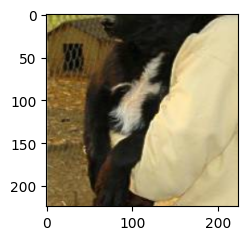

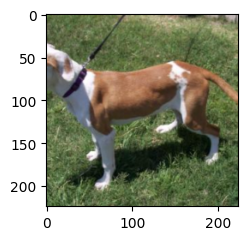

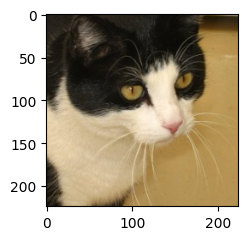

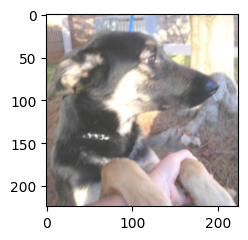

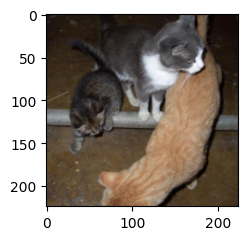

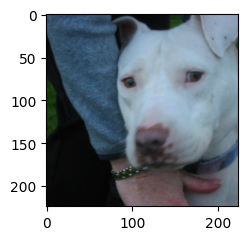

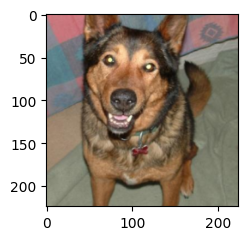

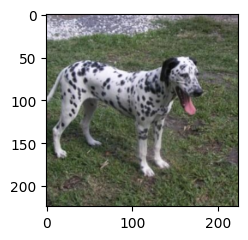

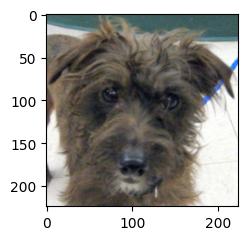

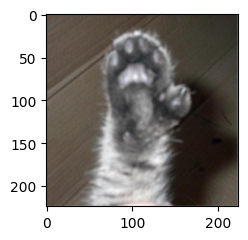

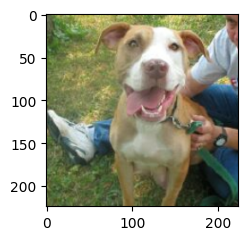

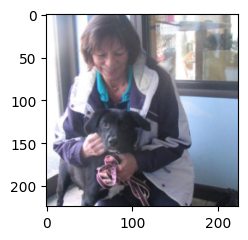

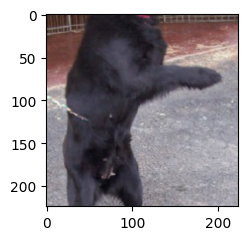

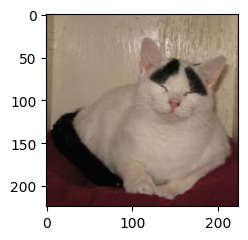

<Figure size 640x480 with 0 Axes>

In [39]:
# 개와 고양이 예측 결과 출력
classes = {0:'cat', 1:'dog'}

daiter = iter(test_loader)
images, labels = next(daiter)
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2,10,idx+1, xticks=[], yticks=[])
  plt.imshow(im_convert(images[idx]))
  ax.set_title(f"{classes[labels[idx].item()]}")
  ax.set_title(f"{str(classes[preds[idx].item()])}({str(classes[labels[idx].item()])})",
               color=('green' if preds[idx]==labels[idx] else 'red'))
  plt.show()
  plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

### 5.3.2 미세 조정 기법
미세 조정 (fine tuning) 기법은 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식. 특성 추출은 목표 특성을 잘 추출했다는 전제하에 좋은 성능을 낼 수 있음. 특성이 잘못 추출되었다면 미세 조정 기법으로 새로운 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있음. 즉, 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학습시키는 것.

- 데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우: 모델 전체를 재학습. 데이터셋 크기가 크기 대문에 재학습시키는 것이 좋은 전략
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우: 합성곱층의 뒷부분과 데이터 분류기를 학습. 데이터셋이 유사하기 때문에 전체 학습보다는 강한 특징이 나타나는 합성곱층의 뒷부분과 데이터 분류기만 새로 학습하더라도 최적의 성능을 낼 수 있음
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우: 합성곱층의 일부분과 데이터 분류기를 학습시킴. 데이터가 적기 때문에 일부 계층의 미세 조정 기법을 적용한다고 해도 효과 없을 수 있음
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우: 데이터 분류기만 학습시킴. 데이터가 적기에 많은 계층에 미세 조정 기법을 적용하면 과적합이 발생할 수 있음

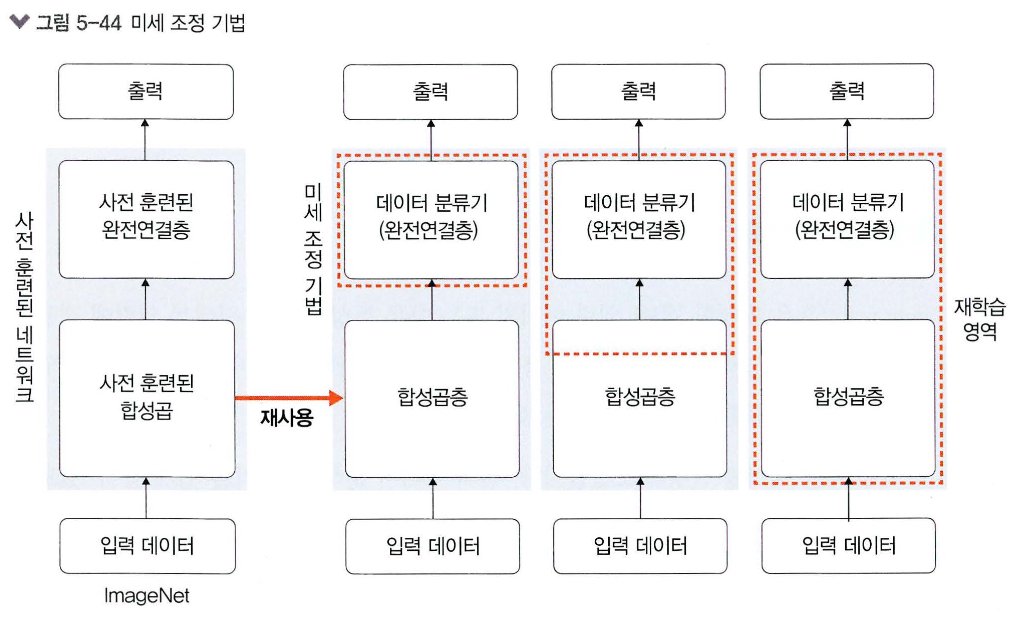